# 1D CNN-A — Temporal Patterns: When Do Market Regimes Appear?

Assigns every clean window a K-Means cluster label and plots those labels
across time — by hour of day, by day of week, and across the full date range —
to reveal intraday and seasonal structure in the discovered market regimes.

> **Prerequisite:** run `1dcnn_train.ipynb` first — it saves `model.pt` to
> `DATA_DIR / SYMBOL /`.

## 1. Imports

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # macOS: prevents libiomp/libomp conflict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from config import Config
from data import (
    load_bars, clean_data, add_features, drop_feature_nans,
    scale_features, make_windows, filter_gap_windows,
)
from model import ConvAutoencoder, WindowDataset, load_model

print(f"PyTorch {torch.__version__} | device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch 2.2.2 | device: cpu


## 2. Config

In [2]:
from config import Config

cfg = Config()

# ── Override defaults here before running the rest of the notebook ────────────
# cfg.MAX_BARS       = None   # load all bars (~552k)
# cfg.EPOCHS         = 30     # full training run
# cfg.N_CLUSTERS     = 12     # try more/fewer clusters
# cfg.LATENT_DIM     = 64     # larger latent space
# cfg.N_SAMPLE       = 5_000  # render more windows in Section 9

# Expose all config fields as module-level names so every downstream cell
# can use SYMBOL, WINDOW_SIZE, LR, feature_cols, DEVICE, etc. unchanged.
globals().update(vars(cfg))

print(f"Symbol={SYMBOL}  Timeframe={TIMEFRAME}  {START_DATE} → {END_DATE}")
print("Using device:", DEVICE)

Symbol=TSLA  Timeframe=1Min  2017-01-01 → 2026-06-11
Using device: cpu


## 3. Fetch Data from Alpaca API
Calls the local `alpaca_api` FastAPI service (must be running: `uv run main.py`).
Fetches TSLA 1-minute bars and saves to both DB and CSV.

In [3]:
if FETCH_DATA:
    import httpx  # only needed when FETCH_DATA = True
    params = {
        "symbols": SYMBOL,
        "timeframe": TIMEFRAME,
        "start": START_DATE,
        "end": END_DATE,
        "save_to": "db,csv",
    }
    with httpx.Client(timeout=None) as client:
        r = client.get(f"{API_BASE}/bars", params=params)
        r.raise_for_status()
        result = r.json()
    bars = result.get("data", {}).get("bars", {}).get(SYMBOL, [])
    print(f"Fetched {len(bars)} bars for {SYMBOL}")
    print("Saved:", result.get("saved"))
else:
    print("FETCH_DATA=False — skipping. Set True in Config to re-pull.")

FETCH_DATA=False — skipping. Set True in Config to re-pull.


## 4. Load Data

In [4]:
# Load raw OHLCV bars from the CSV file.
df = load_bars(DATA_DIR, SYMBOL, TIMEFRAME, MAX_BARS)

Loaded 2,000 bars  |  2020-07-27 13:30:00+00:00 → 2020-08-10 17:55:00+00:00  |  MAX_BARS=2,000


Check for:

Duplicate timestamps
Missing timestamps (gaps)
NaNs
Infinite values
Bad OHLC relationships (high < low, etc.)

Typical checks:

In [5]:
# Remove duplicate timestamps and rows with missing values.
df = clean_data(df)

clean_data: removed 0 rows  →  2,000 remaining


## 5. Verify Time Continuity
A CNN assumes a consistent sequence.

Look for:

missing bars
duplicate bars
irregular spacing

If you're using 1-minute candles, every row should be exactly 1 minutes apart.

In [6]:
delta = df["timestamp"].diff()
dt = pd.to_timedelta(delta).dt.total_seconds()
print("Average time delta (seconds):", dt.mean())
print("Time delta distribution (seconds):")
print(dt.describe())

Average time delta (seconds): 613.0565282641321
Time delta distribution (seconds):
count      1999.000000
mean        613.056528
std        8435.323022
min          60.000000
25%          60.000000
50%          60.000000
75%         120.000000
max      235860.000000
Name: timestamp, dtype: float64


## 6. Add Features

In [7]:
# Calculate 14 technical indicator columns (EMAs, MACD, candle shape, returns, volume ratio).
df = add_features(df)

add_features: appended 14 columns  →  21 total columns


## 6. Remove Initial NaNs

Feature engineering creates NaNs.

In [8]:
# Drop the warm-up rows where EMAs and rolling means don't have enough history yet.
df = drop_feature_nans(df)

drop_feature_nans: removed 19 warm-up rows  →  1,981 remaining


## 7. Scale Features

This is critical.

CNNs train poorly on:

close = 45000
volume = 10000000
return = 0.001

all mixed together.

StandardScaler

Most common:

In [9]:
# Normalise every feature column so they all sit in a similar numeric range.
# RobustScaler uses the median and IQR — better than mean/std for financial data with outliers.
df, scaler = scale_features(df, feature_cols)

scale_features: 14 columns normalised with RobustScaler


## 8. Create Fixed-Length Windows

A CNN does not ingest an entire dataframe.

It ingests samples.

In [10]:
# Slice the time series into overlapping WINDOW_SIZE-bar windows.
# Each window is one training sample for the CNN.
X_raw = make_windows(df, feature_cols, WINDOW_SIZE)
n_features = len(feature_cols)

make_windows: 1,918 windows of shape (64 bars × 14 features)


## 11. Filter Gap Windows
A window that spans an overnight or weekend gap mixes pre-gap and post-gap bars — the CNN would learn noise, not patterns. Any window whose 64-bar span crosses a gap > 5 minutes is dropped.

In [11]:
# Remove windows that span overnight or weekend gaps.
# Such windows would teach the model noise rather than real patterns.
X_clean, valid_mask = filter_gap_windows(X_raw, df, WINDOW_SIZE)

filter_gap_windows: 128 gaps found  |  removed 1,593 windows  |  325 clean windows remain


## 13. Autoencoder Model
Encoder compresses `(batch, 14, 64)` → latent vector `(batch, LATENT_DIM)`.
Decoder reconstructs `(batch, 14, 64)` from the latent vector.
Training loss is reconstruction MSE — no labels needed.

In [12]:
# ConvAutoencoder is defined in model.py — import it at the top.
# Here we just create an instance and move it to the device (CPU or GPU).
model = ConvAutoencoder(n_features=n_features, latent_dim=LATENT_DIM).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")
print(model)

Parameters: 141,742
ConvAutoencoder(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv1d(14, 32, kernel_size=(3,), stride=(1,), padding=(1,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
      (4): ReLU()
      (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (6): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
      (7): ReLU()
      (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (fc): Linear(in_features=1024, out_features=32, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=32, out_features=1024, bias=True)
    (deconv): Sequential(
      (0): ConvTranspose1d(128, 64, kernel_size=(4,), stride=(2,), padding=(1,))
      (1): ReLU()
      (2): ConvTranspose1d(64, 32, kernel_size=(4,), stride=(2,), padding=(1,))
      (3): ReLU()
      (4):

In [13]:
# WindowDataset is defined in model.py and imported at the top.
# It wraps a tensor so PyTorch's DataLoader can iterate it in batches.
# (No code needed here — the import at the top handles it.)

In [14]:
# Load the weights saved by 1dcnn_train.ipynb.
# load_model() builds an empty ConvAutoencoder and fills it with the saved weights.
model = load_model(DATA_DIR, SYMBOL, n_features, LATENT_DIM, DEVICE)

Model loaded ← ../../data/TSLA/model.pt  (device=cpu)


## 15. Extract Latent Vectors & Assign Cluster Labels

In [15]:
from sklearn.cluster import KMeans

all_loader = DataLoader(WindowDataset(
    torch.tensor(X_clean).permute(0, 2, 1)
), batch_size=BATCH_SIZE, shuffle=False)

model.eval()
Z_list = []
with torch.no_grad():
    for batch in all_loader:
        Z_list.append(model.encoder(batch.to(DEVICE)).cpu().numpy())

Z = np.concatenate(Z_list)   # (N_clean, LATENT_DIM)
print(f'Latent matrix Z: {Z.shape}')

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
labels = kmeans.fit_predict(Z)   # (N_clean,)
print('Cluster sizes:', dict(zip(*np.unique(labels, return_counts=True))))

Latent matrix Z: (325, 32)
Cluster sizes: {0: 73, 1: 57, 2: 53, 3: 31, 4: 20, 5: 14, 6: 51, 7: 26}


/Volumes/My SSD/Chris Stuff/DEV/1DCNN_A/.venv/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


## 18. Attach Timestamps to Clean Windows

In [16]:
# Each window ends at bar (i + WINDOW_SIZE - 1); we tag it with that bar's timestamp.
# valid_mask (built in gap-filter cell) maps clean window index → original bar index.
valid_indices = np.where(valid_mask)[0]          # original bar positions of clean windows
window_end_idx = valid_indices + WINDOW_SIZE - 1 # last bar of each window
window_end_idx = np.clip(window_end_idx, 0, len(df) - 1)

timestamps = pd.to_datetime(df['timestamp'].iloc[window_end_idx].values)

regime_df = pd.DataFrame({
    'timestamp': timestamps,
    'cluster':   labels,
})
regime_df['hour']    = regime_df['timestamp'].dt.hour + regime_df['timestamp'].dt.minute / 60
regime_df['weekday'] = regime_df['timestamp'].dt.day_name()
regime_df['date']    = regime_df['timestamp'].dt.normalize()

print(f'regime_df: {len(regime_df):,} rows  |  date range: '
      f'{regime_df["timestamp"].min().date()} → {regime_df["timestamp"].max().date()}')

regime_df: 325 rows  |  date range: 2020-07-28 → 2020-08-10


## 19. Full-Timeline Scatter

Each dot is one 64-bar window, coloured by its cluster. Vertical bands of colour
indicate sustained market regimes; rapid colour switching = volatile transitions.

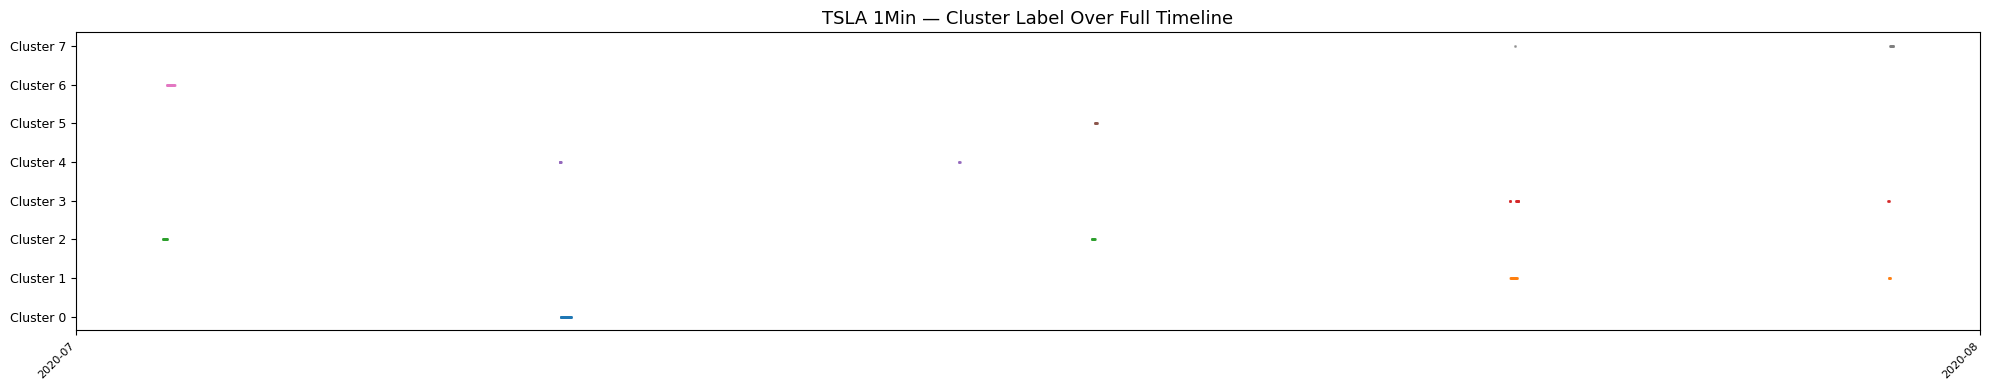

In [17]:
import matplotlib.dates as mdates

cmap = plt.get_cmap('tab10')

fig, ax = plt.subplots(figsize=(20, 4))
for k in range(N_CLUSTERS):
    mask = regime_df['cluster'] == k
    ax.scatter(regime_df.loc[mask, 'timestamp'], [k] * mask.sum(),
               c=[cmap(k)], s=1, alpha=0.4, label=f'Cluster {k}')

ax.set_yticks(range(N_CLUSTERS))
ax.set_yticklabels([f'Cluster {k}' for k in range(N_CLUSTERS)], fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_title(f'{SYMBOL} {TIMEFRAME} — Cluster Label Over Full Timeline', fontsize=13)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.show()

## 20. Hour-of-Day Heatmap

What time of day does each market regime tend to appear?
Bright cells = that cluster frequently occurs at that hour.

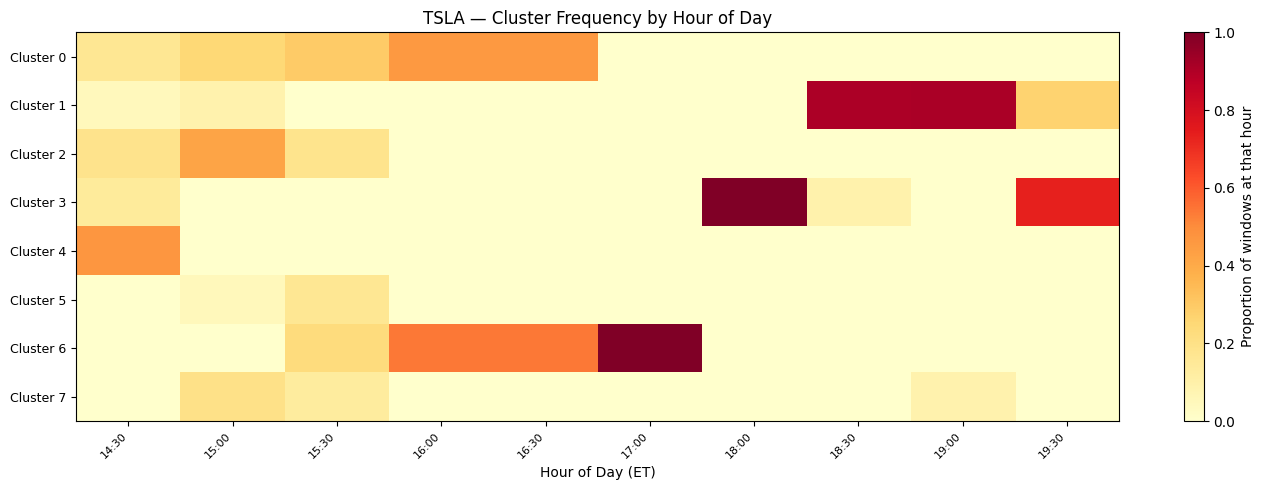

In [18]:
# Count occurrences per cluster per hour-bin (30-min bins)
regime_df['hour_bin'] = (regime_df['hour'] * 2).astype(int) / 2  # round to 0.5h
heatmap_data = (
    regime_df.groupby(['hour_bin', 'cluster'])
    .size()
    .unstack(fill_value=0)
)
# Normalise each hour row so colours show proportion rather than raw count
heatmap_norm = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(heatmap_norm.T, aspect='auto', cmap='YlOrRd', vmin=0)
ax.set_xticks(range(len(heatmap_norm.index)))
ax.set_xticklabels(
    [f'{int(h):02d}:{int((h % 1) * 60):02d}' for h in heatmap_norm.index],
    rotation=45, ha='right', fontsize=8
)
ax.set_yticks(range(N_CLUSTERS))
ax.set_yticklabels([f'Cluster {k}' for k in range(N_CLUSTERS)], fontsize=9)
ax.set_xlabel('Hour of Day (ET)')
ax.set_title(f'{SYMBOL} — Cluster Frequency by Hour of Day', fontsize=12)
plt.colorbar(im, ax=ax, label='Proportion of windows at that hour')
plt.tight_layout()
plt.show()

## 21. Day-of-Week Distribution

Does any cluster dominate a particular weekday?
Seasonal trading patterns (Monday gaps, Friday de-risking) often show up here.

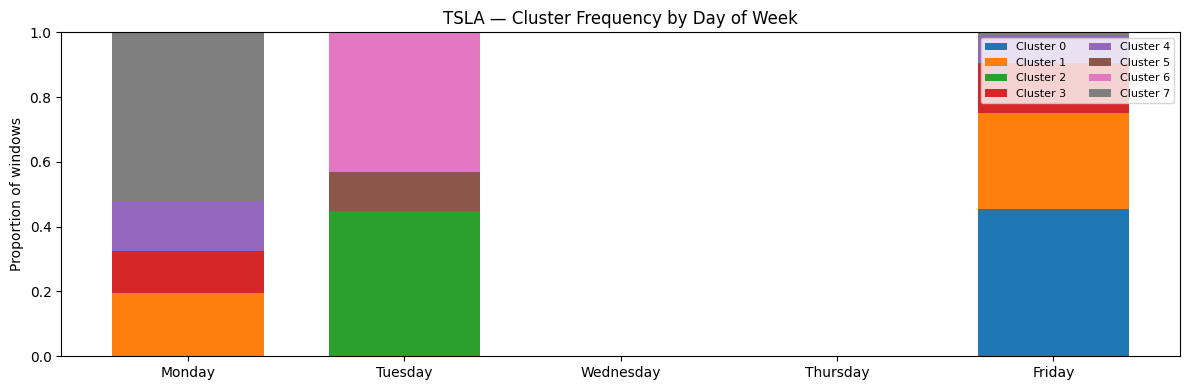

In [19]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
day_data = (
    regime_df.groupby(['weekday', 'cluster'])
    .size()
    .unstack(fill_value=0)
    .reindex(day_order)
)
day_norm = day_data.div(day_data.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
bottom = np.zeros(len(day_order))
for k in range(N_CLUSTERS):
    vals = day_norm[k].values if k in day_norm.columns else np.zeros(len(day_order))
    ax.bar(day_order, vals, bottom=bottom, color=cmap(k), label=f'Cluster {k}', width=0.7)
    bottom += vals

ax.set_ylabel('Proportion of windows')
ax.set_title(f'{SYMBOL} — Cluster Frequency by Day of Week', fontsize=12)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 22. What You're Seeing

### Full-Timeline Scatter
Long runs of the same colour = sustained market regimes (e.g. a trending week, earnings volatility).
Rapid colour switching = choppy, transitional markets.

### Hour-of-Day Heatmap
Common patterns in TSLA 1-minute data:
- **Open volatility cluster** (9:30–10:00 ET) — high `volume_ratio`, wide candles
- **Lunchtime lull cluster** (12:00–13:00 ET) — flat `macd`, low `volume_ratio`
- **Close cluster** (15:30–16:00 ET) — rising volume, directional momentum

### Day-of-Week
Monday and Friday often have distinct distributions due to gap risk and
position-squaring. If one cluster is Monday-heavy, inspect its centroids
in `latent_cluster.ipynb` for gap-open characteristics.

**Next step:** take any cluster that stands out here and look at its centroid
line plot in `latent_cluster.ipynb` to understand what the pattern actually looks like.